In [1]:
import sys
sys.path.append("..")
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import json
from datetime import datetime
from datasets import load_from_disk
from torch.utils.data import DataLoader

In [2]:
# Загрузка модели, корневая папка проекта
from src.data import PROJECT_ROOT, load_model_and_tokenizer, RuleTakerDataset, estimate_max_length, create_minimal_pairs, compute_differential_stats, analyze_neuron_activations
from src.probing import run_probing_experiment, load_probing_results
from src.llm_upgrade import wrap_for_transformer_lens

In [3]:
sns.set_style("whitegrid")

In [4]:
CACHE_DIR = PROJECT_ROOT / "data/processed"
RESULTS_DIR = PROJECT_ROOT / "results/probing"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Эксперименты по зондированию на Pythia-1b

## Эксперимент 8-2: Pythia-1b (seq QLoRA) + depth-1

In [5]:
# Параметры эксперимента
VARIANT = "depth-1"
MODEL_SIZE = "1b"
BASE_MODEL_NAME = "EleutherAI/pythia-1b-deduped"
ADAPTER_PATH = PROJECT_ROOT / "results/checkpoints/finetune/exp8-2/checkpoint-1000"
USE_SMALL = True
HOOK_NAME = "resid_post"
POOLING = "last"
BATCH_SIZE = 16

### Подготовка модели и данных

In [6]:
hooked_model, tokenizer = wrap_for_transformer_lens(
    base_model_name=BASE_MODEL_NAME,
    adapter_path=str(ADAPTER_PATH),
    device="cuda"
)
hooked_model.eval()

`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model EleutherAI/pythia-1b-deduped into HookedTransformer


HookedTransformer(
  (embed): Embed()
  (hook_embed): HookPoint()
  (blocks): ModuleList(
    (0-15): 16 x TransformerBlock(
      (ln1): LayerNorm(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (ln2): LayerNorm(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (attn): Attention(
        (hook_k): HookPoint()
        (hook_q): HookPoint()
        (hook_v): HookPoint()
        (hook_z): HookPoint()
        (hook_attn_scores): HookPoint()
        (hook_pattern): HookPoint()
        (hook_result): HookPoint()
        (hook_rot_k): HookPoint()
        (hook_rot_q): HookPoint()
      )
      (mlp): MLP(
        (hook_pre): HookPoint()
        (hook_post): HookPoint()
      )
      (hook_attn_in): HookPoint()
      (hook_q_input): HookPoint()
      (hook_k_input): HookPoint()
      (hook_v_input): HookPoint()
      (hook_mlp_in): HookPoint()
      (hook_attn_out): HookPoint()
      (hook_mlp_out): HookPoint()
    

In [7]:
# Загружаем усеченную версию датасета
cache_suffix = f"{VARIANT}_small" if USE_SMALL else VARIANT
cache_path = CACHE_DIR / f"ruletaker_{cache_suffix}"
dataset = load_from_disk(str(cache_path))

In [8]:
# если выборка до 5000 наблюдений
tmp_tokens = tokenizer(list(dataset["train"]["text"]), padding=False, truncation=False)
lengths = [len(ids) for ids in tmp_tokens['input_ids']]
max_full = max(lengths)
max_p95 = int(np.percentile(lengths, 95))
print(f"95-й перцентиль: {max_p95} токенов (при макс длине {max_full})")

95-й перцентиль: 195 токенов (при макс длине 257)


In [10]:
# max_p95 = estimate_max_length(list(dataset["train"]["text"]), tokenizer, percentile=95, sample_size=500)

In [9]:
MAX_LENGTH = max_p95

In [10]:
train_dataset = RuleTakerDataset(dataset["train"], tokenizer, max_length=MAX_LENGTH)
dev_dataset = RuleTakerDataset(dataset["dev"], tokenizer, max_length=MAX_LENGTH)

In [11]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
dev_loader   = DataLoader(dev_dataset, batch_size=BATCH_SIZE, shuffle=False)

### Метод probing classifiers

In [12]:
n_layers = hooked_model.cfg.n_layers
d_model = hooked_model.cfg.d_model

In [13]:
n_layers

16

In [14]:
torch.cuda.empty_cache()

In [15]:
# Кэшируем активации
results = run_probing_experiment(
    hooked_model, train_loader, dev_loader, n_layers,
    hook_name=HOOK_NAME, pooling=POOLING
)

Probing layers:  94%|█████████▍| 15/16 [19:09<01:18, 78.95s/it]c:\MyPythonProjects\mephi_diss\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
Probing layers: 100%|██████████| 16/16 [20:28<00:00, 76.81s/it]


In [16]:
# Извлечение данных для графиков
train_accs = results["train_accs"]
dev_accs = results["dev_accs"]
train_means = [s["mean_abs"] for s in results["train_stats"]]
dev_means = [s["mean_abs"] for s in results["dev_stats"]]
train_stds = [s["std_abs"] for s in results["train_stats"]]
dev_stds = [s["std_abs"] for s in results["dev_stats"]]
train_sparsity = [s["sparsity"] for s in results["train_stats"]]
dev_sparsity = [s["sparsity"] for s in results["dev_stats"]]

In [17]:
# Визуализация результатов
best_layer = int(np.argmax(dev_accs))
best_train_acc = float(train_accs[best_layer])
best_dev_acc = float(dev_accs[best_layer])
print(f"Лучший слой: {best_layer} (0-based), Dev Accuracy: {best_dev_acc:.4f}")

Лучший слой: 13 (0-based), Dev Accuracy: 0.6040


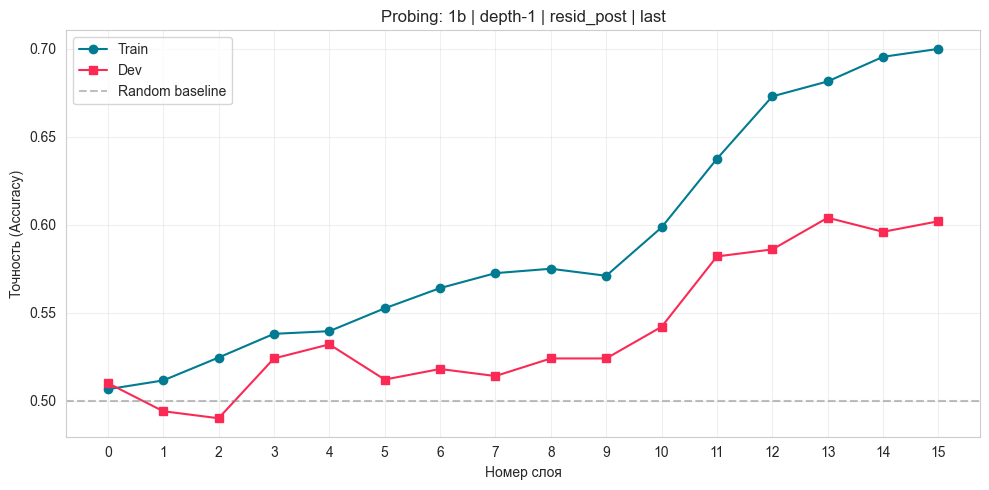

In [18]:
plt.figure(figsize=(10, 5))
x = np.arange(n_layers)
plt.plot(x, train_accs, marker="o", label="Train", color="xkcd:ocean")
plt.plot(x, dev_accs, marker="s", label="Dev", color="xkcd:red pink")
plt.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="Random baseline")
plt.xlabel("Номер слоя")
plt.ylabel("Точность (Accuracy)")
plt.title(f"Probing: {MODEL_SIZE} | {VARIANT} | {HOOK_NAME} | {POOLING}")
plt.xticks(x)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

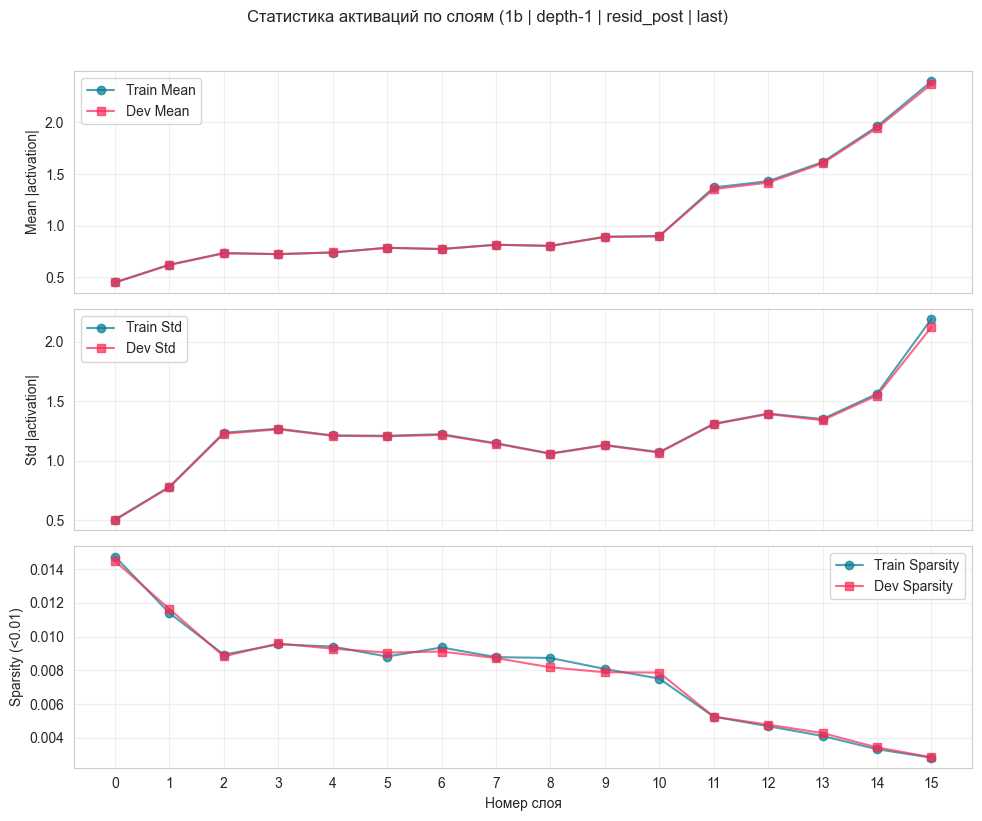

In [19]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

ax1.plot(x, train_means, marker="o", label="Train Mean", color="xkcd:ocean", alpha=0.7)
ax1.plot(x, dev_means, marker="s", label="Dev Mean", color="xkcd:red pink", alpha=0.7)
ax1.set_ylabel("Mean |activation|")
ax1.set_xticks(x)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(x, train_stds, marker="o", label="Train Std", color="xkcd:ocean", alpha=0.7)
ax2.plot(x, dev_stds, marker="s", label="Dev Std", color="xkcd:red pink", alpha=0.7)
ax2.set_ylabel("Std |activation|")
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3.plot(x, train_sparsity, marker="o", label="Train Sparsity", color="xkcd:ocean", alpha=0.7)
ax3.plot(x, dev_sparsity, marker="s", label="Dev Sparsity", color="xkcd:red pink", alpha=0.7)
ax3.set_ylabel("Sparsity (<0.01)")
ax3.set_xlabel("Номер слоя")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.suptitle(f"Статистика активаций по слоям ({MODEL_SIZE} | {VARIANT} | {HOOK_NAME} | {POOLING})", y=1.02)
plt.tight_layout()
plt.show()

In [20]:
# Сохранение метрик в JSON
fname = f"probe_{MODEL_SIZE}(seq_QLoRA)_{VARIANT}_{HOOK_NAME}_{POOLING}.json"
fpath = RESULTS_DIR / fname

In [21]:
metrics = {
    "variant": VARIANT,
    "model_size": MODEL_SIZE,
    "hook_name": HOOK_NAME,
    "pooling": POOLING,
    "best_layer": best_layer,
    "best_dev_acc": float(best_dev_acc),
    "train_accs": [float(a) for a in train_accs],
    "dev_accs": [float(a) for a in dev_accs]
}

# Исходные условия эксперимента
metadata = {
    "experiment_type": "probing_layer_selection",
    "timestamp": datetime.now().isoformat(),
    "variant": VARIANT,
    "model_size": MODEL_SIZE,
    "hook_name": HOOK_NAME,
    "pooling": POOLING,
    "batch_size": BATCH_SIZE,
    "max_length": MAX_LENGTH
}

# Основной результат
summary = {
    "best_layer": best_layer,
    "best_train_acc": best_train_acc,
    "best_dev_acc": best_dev_acc,
    "n_layers": len(results["layers"])
}

# Свод
full_data = {
    "metadata": metadata,
    "summary": summary,
    "layers": results["layers"],
    "train_accs": [float(x) for x in results["train_accs"]],
    "dev_accs": [float(x) for x in results["dev_accs"]],
    "train_stats": results["train_stats"],
    "dev_stats": results["dev_stats"]
}

with open(fpath, "w", encoding="utf-8") as f:
    json.dump(full_data, f, indent=2, ensure_ascii=False)
print(f"Результаты сохранены: {fpath}")

Результаты сохранены: C:\MyPythonProjects\mephi_diss\results\probing\probe_1b(seq_QLoRA)_depth-1_resid_post_last.json


### Проверка токенизации

In [23]:
# Список ключевых слов для проверки
logic_keywords = ["if", "then", "and", "or", "not", "implies", "is", "are", "all", "some", "no"]

In [24]:
# Возьмём несколько примеров из датасета (первые 3 из train)
sample_texts = list(dataset["train"]["text"])[:3]

In [25]:
for i, text in enumerate(sample_texts):
    print(f"Пример {i+1}:\n{text[:300]}...\n")  # первые 300 символов
    tokens = tokenizer.tokenize(text)
    print(f"Токены (первые 50): {tokens[:50]}\n")

    # Проверка каждого ключевого слова
    print("Наличие ключевых слов в тексте и токенах:")
    for kw in logic_keywords:
        in_text = kw in text.lower()
        # ищем токен, совпадающий с kw (без учёта регистра)
        in_tokens = any(tok.lstrip("Ġ").lower() == kw for tok in tokens)
        print(f"  '{kw}': в тексте={in_text}, в токенах={in_tokens}")
    print("-" * 80)

Пример 1:
Anne is quiet. Anne is not young. Bob is kind. Bob is young. Dave is rough. Dave is round. Dave is smart. Dave is not young. Fiona is quiet. Fiona is not round. Kind, young things are not smart. Bob is kind....

Токены (первые 50): ['Anne', 'Ġis', 'Ġquiet', '.', 'ĠAnne', 'Ġis', 'Ġnot', 'Ġyoung', '.', 'ĠBob', 'Ġis', 'Ġkind', '.', 'ĠBob', 'Ġis', 'Ġyoung', '.', 'ĠDave', 'Ġis', 'Ġrough', '.', 'ĠDave', 'Ġis', 'Ġround', '.', 'ĠDave', 'Ġis', 'Ġsmart', '.', 'ĠDave', 'Ġis', 'Ġnot', 'Ġyoung', '.', 'ĠF', 'iona', 'Ġis', 'Ġquiet', '.', 'ĠF', 'iona', 'Ġis', 'Ġnot', 'Ġround', '.', 'ĠKind', ',', 'Ġyoung', 'Ġthings', 'Ġare']

Наличие ключевых слов в тексте и токенах:
  'if': в тексте=False, в токенах=False
  'then': в тексте=False, в токенах=False
  'and': в тексте=False, в токенах=False
  'or': в тексте=False, в токенах=False
  'not': в тексте=True, в токенах=True
  'implies': в тексте=False, в токенах=False
  'is': в тексте=True, в токенах=True
  'are': в тексте=True, в токенах=True
  'all'

In [26]:
# Токенизация самих ключевых слов как отдельных строк
for kw in logic_keywords:
    tokens_kw = tokenizer.tokenize(kw)
    is_single = len(tokens_kw) == 1
    print(f"'{kw}' -> {tokens_kw} (цельный токен: {is_single})")

'if' -> ['if'] (цельный токен: True)
'then' -> ['then'] (цельный токен: True)
'and' -> ['and'] (цельный токен: True)
'or' -> ['or'] (цельный токен: True)
'not' -> ['not'] (цельный токен: True)
'implies' -> ['impl', 'ies'] (цельный токен: False)
'is' -> ['is'] (цельный токен: True)
'are' -> ['are'] (цельный токен: True)
'all' -> ['all'] (цельный токен: True)
'some' -> ['some'] (цельный токен: True)
'no' -> ['no'] (цельный токен: True)


### Разностный анализ активаций

In [27]:
data = load_probing_results(f"{MODEL_SIZE}(seq_qLoRA)", VARIANT, HOOK_NAME, POOLING)

In [28]:
data

{'metadata': {'experiment_type': 'probing_layer_selection',
  'timestamp': '2026-05-15T19:13:35.832472',
  'variant': 'depth-1',
  'model_size': '1b',
  'hook_name': 'resid_post',
  'pooling': 'last',
  'batch_size': 16,
  'max_length': 195},
 'summary': {'best_layer': 13,
  'best_train_acc': 0.6815,
  'best_dev_acc': 0.604,
  'n_layers': 16},
 'layers': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
 'train_accs': [0.5065,
  0.5115,
  0.5245,
  0.538,
  0.5395,
  0.5525,
  0.564,
  0.5725,
  0.575,
  0.571,
  0.5985,
  0.6375,
  0.673,
  0.6815,
  0.6955,
  0.7],
 'dev_accs': [0.51,
  0.494,
  0.49,
  0.524,
  0.532,
  0.512,
  0.518,
  0.514,
  0.524,
  0.524,
  0.542,
  0.582,
  0.586,
  0.604,
  0.596,
  0.602],
 'train_stats': [{'mean_abs': 0.45104336738586426,
   'std_abs': 0.5072669386863708,
   'max_abs': 19.375,
   'min_abs': 0.0,
   'sparsity': 0.014747802734375,
   'mean_by_neuron': 0.14301812648773193,
   'condition_number': inf,
   'effective_rank': 1.0,
   'max_s

In [29]:
DIFF_LAYER = data["summary"]["best_layer"]

In [30]:
pairs = create_minimal_pairs(variant=VARIANT, n_pairs=30)

In [31]:
diff_stats = compute_differential_stats(
    hooked_model, tokenizer, pairs,
    layer_idx=DIFF_LAYER,
    hook_name=HOOK_NAME,
    pooling=POOLING,
    max_length=data["metadata"]["max_length"]   # или из MAX_LENGTH
)

In [32]:
print(f"Средняя абсолютная разница активаций: {diff_stats['mean_abs_diff']:.4f}")
print(f"Стандартное отклонение разницы: {diff_stats['std_diff']:.4f}")

Средняя абсолютная разница активаций: 0.0322
Стандартное отклонение разницы: 0.0347


In [33]:
neuron_sens = diff_stats['neuron_sensitivity']
top_neurons = np.argsort(neuron_sens)[-100:][::-1]
print("Топ-100 нейронов с наибольшей средней разницей:")
for i, n in enumerate(top_neurons):
    print(f"  Нейрон {n}: {neuron_sens[n]:.4f}")

Топ-100 нейронов с наибольшей средней разницей:
  Нейрон 1668: 0.3042
  Нейрон 232: 0.2240
  Нейрон 1638: 0.2167
  Нейрон 1429: 0.1385
  Нейрон 1467: 0.1125
  Нейрон 1559: 0.0812
  Нейрон 490: 0.0760
  Нейрон 1944: 0.0719
  Нейрон 1362: 0.0674
  Нейрон 1549: 0.0667
  Нейрон 1878: 0.0666
  Нейрон 1034: 0.0609
  Нейрон 1946: 0.0604
  Нейрон 379: 0.0583
  Нейрон 1764: 0.0582
  Нейрон 1427: 0.0573
  Нейрон 127: 0.0564
  Нейрон 1367: 0.0562
  Нейрон 264: 0.0555
  Нейрон 1866: 0.0547
  Нейрон 975: 0.0542
  Нейрон 222: 0.0536
  Нейрон 1462: 0.0536
  Нейрон 714: 0.0531
  Нейрон 1280: 0.0531
  Нейрон 807: 0.0531
  Нейрон 193: 0.0529
  Нейрон 1482: 0.0526
  Нейрон 897: 0.0522
  Нейрон 1443: 0.0521
  Нейрон 85: 0.0517
  Нейрон 1754: 0.0516
  Нейрон 1758: 0.0510
  Нейрон 13: 0.0508
  Нейрон 454: 0.0505
  Нейрон 451: 0.0505
  Нейрон 544: 0.0505
  Нейрон 1724: 0.0500
  Нейрон 656: 0.0500
  Нейрон 357: 0.0500
  Нейрон 434: 0.0500
  Нейрон 1809: 0.0495
  Нейрон 1134: 0.0495
  Нейрон 210: 0.0493
  Нейр

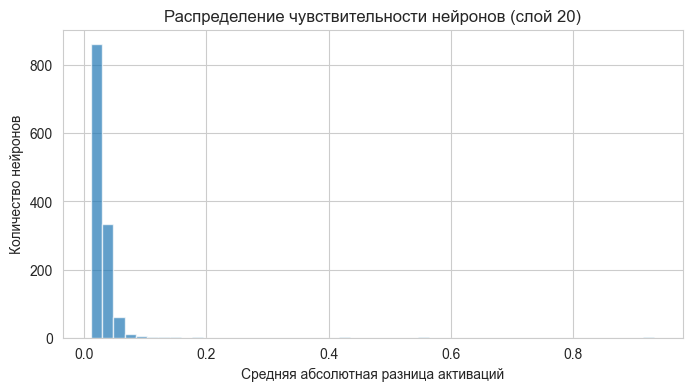

In [36]:
# Гистограмма чувствительности нейронов
plt.figure(figsize=(8,4))
plt.hist(neuron_sens, bins=50, alpha=0.7)
plt.xlabel("Средняя абсолютная разница активаций")
plt.ylabel("Количество нейронов")
plt.title(f"Распределение чувствительности нейронов (слой {DIFF_LAYER})")
plt.grid(True)
plt.show()

In [37]:
# Добавляем результаты разностного анализа в файл json с результатами пробинга
diff_stats["neuron_sensitivity"] = diff_stats["neuron_sensitivity"].tolist()
data["diff_stats"] = diff_stats
with open(fpath, "w", encoding="utf-8") as f:
    json.dump(data, f, indent=2, ensure_ascii=False)
    print(f"Результаты разностного анализа добавлены в {fpath}")

Результаты разностного анализа добавлены в C:\MyPythonProjects\mephi_diss\results\probing\probe_gpt2-large(seq_QLoRA)_depth-1_resid_post_last.json


In [34]:
top_texts, top_tokens = analyze_neuron_activations(
    hooked_model, tokenizer,
    layer_idx=13, neuron_idx=1668,
    texts=list(dataset["train"]["text"])[:200],
    top_k_examples=10,
    top_k_tokens=30
)

In [35]:
print("Топ-10 примеров для нейрона 1668:")
for text, act in top_texts:
    print(f"  [{act:.3f}] {text}")

Топ-10 примеров для нейрона 1668:
  [-2.875] The bald eagle chases the mouse. The bald eagle is big. The bald eagle is blue. The bald eagle is cold. The bald eagle is nice. The bald eagle is round. The bald eagle needs the mouse. The bald eagle visits the mouse. The mouse chases the bald eagle. The mouse is big. The mouse is blue. The mouse is cold. The mouse is round. The mouse needs the bald eagle. The mouse visits the bald eagle. If someone needs the mouse then the mouse needs the bald eagle. If the mouse is round and the mouse needs the bald eagle then the mouse is nice. The mouse does not chase the bald eagle.
  [-4.906] The bear eats the mouse. The bear is blue. The bear is cold. The bear is green. The bear is not kind. The bear is rough. The bear does not need the mouse. The bear visits the mouse. The mouse eats the bear. The mouse is blue. The mouse is cold. The mouse is green. The mouse is kind. The mouse is rough. The mouse needs the bear. The mouse visits the bear. If the be

In [36]:
print("Топ-30 токенов для нейрона 1668:")
for token, score in top_tokens:
    print(f"{token.strip()}: {score:+.3f}")

Топ-30 токенов для нейрона 1668:
All: +60.403
The: +58.021
cold: +57.395
are: +56.455
not: +56.133
is: +53.207
smart: +52.904
round: +52.431
,: +52.036
Smart: +51.000
blue: +50.780
young: +50.270
big: +50.043
rough: +49.359
nice: +49.305
Bob: +48.184
quiet: +47.865
kind: +47.780
white: +46.902
ry: +46.503
Charlie: +46.500
green: +46.459
F: +46.351
Dave: +46.250
Rough: +46.023
If: +45.973
lion: +45.406
cat: +45.319
then: +44.477
red: +43.507
